# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Gomez, Laura`
- Apellido2, Nombre2: `Ramirez, Alejandro`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [4]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1017929190
cedula2 = 1000411835

In [5]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 25
Parámetros — alpha: 2.20, beta: 1.00, gamma: 0.160, ruido: 0.170
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Significado de interpolar Z_data y si pasa exactamente por los valores:
Interpolar Z_data significa que el método matemático obliga a la superficie generada a pasar exactamente por cada uno de los 225 puntos registrados. Sí, el spline pasará exactamente por los valores de Z_data. El problema de esto es que la superficie no solo está modelando el terreno real (Z_true), sino que está "memorizando" el ruido aleatorio añadido, lo que genera una superficie arrugada o con picos artificiales (sobreajuste).

b) Cuándo preferir mínimos cuadrados:
Es preferible usar mínimos cuadrados cuando sabemos que los datos tienen ruido (errores de medición o variaciones aleatorias) y queremos descubrir la tendencia general subyacente (Z_true). A diferencia del spline, los mínimos cuadrados no obligan a la superficie a tocar los puntos exactos, sino que minimizan el error global, actuando como un filtro que ignora las anomalías locales.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) Construcción de la matriz $A$:Para el modelo $z = c_0 + c_1x + c_2y$, la matriz $A$ (de tamaño $225 \times 3$) se construye ensamblando tres columnas verticales:Primera columna: Un vector lleno de unos (1). Corresponde al término independiente $c_0$.Segunda columna: Un vector con todas las coordenadas $x$ de la malla aplanadas. Corresponde al coeficiente $c_1$.Tercera columna: Un vector con todas las coordenadas $y$ de la malla aplanadas. Corresponde al coeficiente $c_2$.

b) Significado del plano ajustado:Aunque Z_true sea una superficie curva y compleja, el plano ajustado representa la tendencia lineal global de la superficie. Geométricamente, nos indica la inclinación principal o el gradiente promedio del terreno en todo el dominio (hacia dónde "cae" o "sube" la montaña a grandes rasgos), ignorando las colinas y valles locales.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Por qué es necesario centrar los datos:
PCA busca las direcciones (vectores) donde los datos tienen la mayor varianza (dispersión). Si no centramos los datos restando la media, el primer componente principal simplemente apuntará desde el origen de coordenadas (0,0,0) hacia el centro de masa de la nube de puntos, lo cual no nos dice nada sobre cómo varía la superficie, sino solo dónde está ubicada en el espacio.

b) Interpretación geométrica del primer componente:
En el contexto de esta nube de puntos 3D, el primer componente principal representa el eje o línea recta a lo largo del cual la superficie presenta su mayor estiramiento o dispersión física. Para un terreno cuadrado, suele alinearse con la diagonal más larga de la superficie o con la dirección que presenta el desnivel más extremo del relieve.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

Forma de Z_spline (Malla Fina): (100, 100)


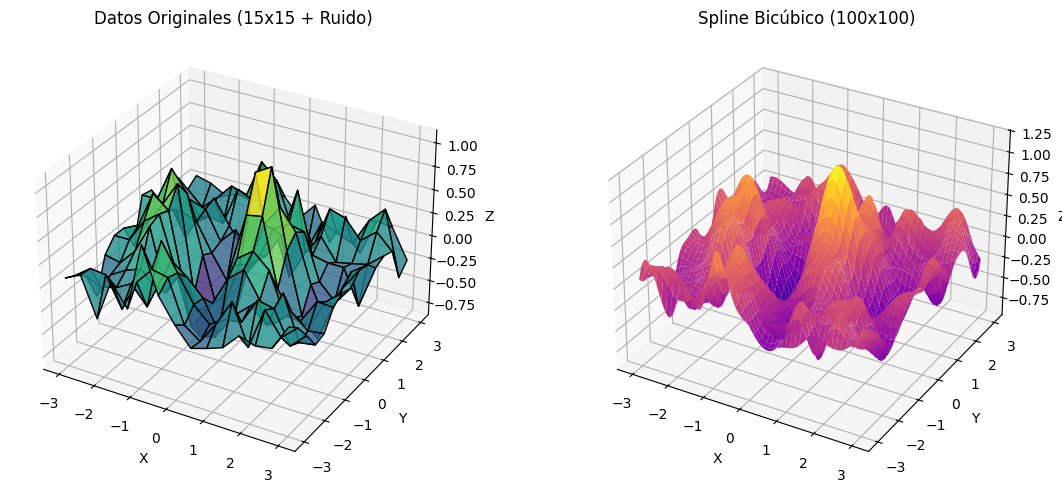

In [6]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
# 1. Crear la malla fina de 100x100 puntos en el intervalo [-3, 3]
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)

# Opcional para graficar después: crear las matrices 2D de la malla fina
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# 2. Construir el spline bicúbico (Tensor Product)
# Pasamos los vectores 1D originales (x_raw, y_raw) y la matriz de alturas (Z_data)
# kx=3 y ky=3 aseguran que sea "cúbico" en ambas direcciones
spline_bicubico = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# 3. Evaluar el spline en la nueva malla fina
# RectBivariateSpline es muy inteligente: le pasas los vectores 1D y él
# te devuelve directamente la matriz 2D (100x100) con las alturas calculadas.
Z_spline = spline_bicubico(x_fine, y_fine)

print(f"Forma de Z_spline (Malla Fina): {Z_spline.shape}")

# ═══════════════════════════════════════════════════════════════
# 4. GRAFICAR (Para que veas la magia en acción)
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 5))

# Gráfico 1: Los datos crudos (15x15) con ruido
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', edgecolor='k', alpha=0.8)
ax1.set_title('Datos Originales (15x15 + Ruido)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Gráfico 2: La superficie suavizada (100x100)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='plasma', edgecolor='none')
ax2.set_title('Spline Bicúbico (100x100)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

Forma de Z_spline (Malla Fina): (100, 100)


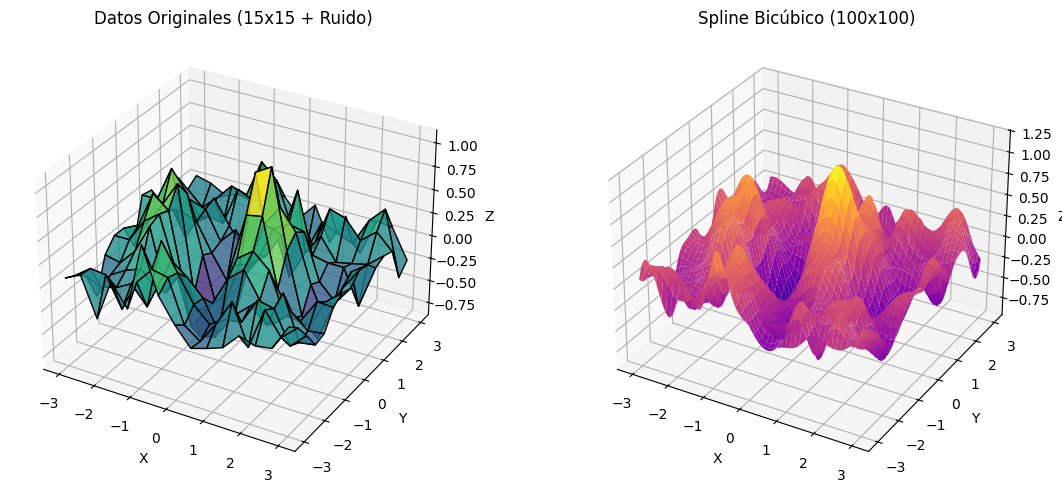

In [7]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
# 1. Crear la malla fina de 100x100 puntos en el intervalo [-3, 3]
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)

# Opcional para graficar después: crear las matrices 2D de la malla fina
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# 2. Construir el spline bicúbico (Tensor Product)
# Pasamos los vectores 1D originales (x_raw, y_raw) y la matriz de alturas (Z_data)
# kx=3 y ky=3 aseguran que sea "cúbico" en ambas direcciones
spline_bicubico = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# 3. Evaluar el spline en la nueva malla fina
# RectBivariateSpline es muy inteligente: le pasas los vectores 1D y él
# te devuelve directamente la matriz 2D (100x100) con las alturas calculadas.
Z_spline = spline_bicubico(x_fine, y_fine)

print(f"Forma de Z_spline (Malla Fina): {Z_spline.shape}")

# ═══════════════════════════════════════════════════════════════
# 4. GRAFICAR (Para que veas la magia en acción)
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 5))

# Gráfico 1: Los datos crudos (15x15) con ruido
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', edgecolor='k', alpha=0.8)
ax1.set_title('Datos Originales (15x15 + Ruido)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Gráfico 2: La superficie suavizada (100x100)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='plasma', edgecolor='none')
ax2.set_title('Spline Bicúbico (100x100)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [8]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
import numpy as np

# 1. Aplanar las matrices (de 15x15 a un vector de 225 elementos)
# Los algoritmos de álgebra lineal necesitan listas planas de puntos, no cuadrículas.
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# 2. Construir la matriz de diseño A
# Queremos ajustar: z = c0*(1) + c1*(x) + c2*(y)
# np.ones_like crea un vector de unos del mismo tamaño que x_flat
A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat))

# 3. Resolver el sistema normal por mínimos cuadrados usando lstsq
# rcond=None es la práctica recomendada en versiones modernas de numpy
coeficientes, residuos, rank, s = np.linalg.lstsq(A, z_flat, rcond=None)

# Extraer los coeficientes
c0, c1, c2 = coeficientes

# 4. Imprimir los resultados con 4 decimales
print("Resultados del Ajuste por Mínimos Cuadrados:")
print(f"c0 = {c0:.4f}")
print(f"c1 = {c1:.4f}")
print(f"c2 = {c2:.4f}")


Resultados del Ajuste por Mínimos Cuadrados:
c0 = 0.0058
c1 = -0.0116
c2 = -0.0034


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

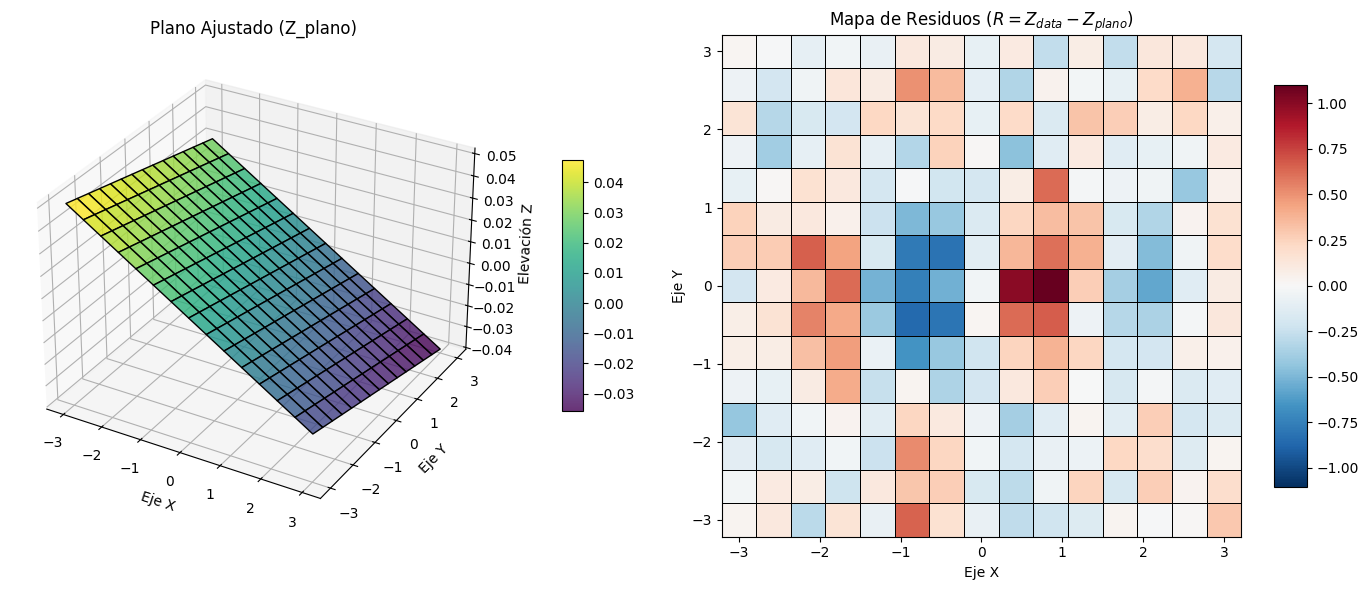

In [9]:
# TODO P3.2: plano ajustado y mapa de residuos
# 1. Calcular Z_plano evaluando la ecuación del plano en la malla gruesa
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# 2. Calcular el mapa de residuos R (Diferencia entre los datos y el plano)
R = Z_data - Z_plano

# 3. Preparar el límite simétrico para el colormap divergente (centrado en 0)
# Buscamos el valor absoluto máximo en los residuos para usarlo como límite positivo y negativo
limite_R = np.max(np.abs(R))

# 4. Crear la figura con los dos paneles
fig = plt.figure(figsize=(14, 6))

# --- PANEL IZQUIERDO: Plano ajustado sobre la malla gruesa (3D) ---
ax1 = fig.add_subplot(121, projection='3d')
surf_plano = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='viridis', edgecolor='k', alpha=0.8)
ax1.set_title('Plano Ajustado (Z_plano)')
ax1.set_xlabel('Eje X')
ax1.set_ylabel('Eje Y')
ax1.set_zlabel('Elevación Z')
# Colorbar y ejes etiquetados como se solicitó
fig.colorbar(surf_plano, ax=ax1, shrink=0.5, aspect=12, pad=0.1)

# --- PANEL DERECHO: Mapa de residuos R (2D Heatmap) ---
# Un mapa 2D (pcolormesh o imshow) es ideal para visualizar mapas de residuos
ax2 = fig.add_subplot(122)
# Usamos 'RdBu_r' (Rojo-Azul) que es un colormap divergente excelente
mapa_residuos = ax2.pcolormesh(X_raw, Y_raw, R,
                               cmap='RdBu_r',
                               vmin=-limite_R,   # Límite negativo exacto
                               vmax=limite_R,    # Límite positivo exacto (Centra en cero)
                               shading='auto',
                               edgecolors='k',
                               linewidth=0.5)
ax2.set_title('Mapa de Residuos ($R = Z_{data} - Z_{plano}$)')
ax2.set_xlabel('Eje X')
ax2.set_ylabel('Eje Y')
# Colorbar para el panel derecho
fig.colorbar(mapa_residuos, ax=ax2, shrink=0.8, aspect=12)

plt.tight_layout()
plt.show()


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [10]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=2.20, omega2=1.00


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
